In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [15]:
# Load PTB-XL metadata
df = pd.read_csv("/users/PLS0150/shreeshtee/PTBXL-Dataset-Thesiswork/physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv")

df.head()


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [16]:
print("Total rows:", len(df))

print("\nAGE COLUMN:")
print(df['age'].head())
print("Unique age values:", df['age'].unique()[:10])

print("\nSEX COLUMN:")
print(df['sex'].head())
print("Unique sex values:", df['sex'].unique())

Total rows: 21799

AGE COLUMN:
0    56.0
1    19.0
2    37.0
3    24.0
4    19.0
Name: age, dtype: float64
Unique age values: [56. 19. 37. 24. 18. 54. 48. 55. 22. 20.]

SEX COLUMN:
0    1
1    0
2    1
3    0
4    1
Name: sex, dtype: int64
Unique sex values: [1 0]


In [18]:
# Make a copy to avoid warnings
df = df.copy()

# ---- FIX 1: DO NOT drop everything ----
# Fill missing values instead
df['age'] = df['age'].fillna(df['age'].median())

# Check sex values before mapping
print("Sex values BEFORE mapping:", df['sex'].unique())

# Fill missing sex safely
df['sex'] = df['sex'].fillna(0)

# Convert sex to readable format
df['sex'] = df['sex'].replace({0: 'Male', 1: 'Female'})

# ---- FIX 2: Create age groups safely ----
bins = [15, 30, 50, 70, 90]
labels = ['Young (15–30)', 'Middle (30–50)', 'Senior (50–70)', 'Elderly (70+)']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# ---- CHECK FOR ANY REMAINING NaN ----
print("\nAge group NaNs:", df['age_group'].isna().sum())

# ---- SUMMARY ----
print("\nNumerical Summary:")
print(df[['age']].describe())

print("\nSex Distribution:")
print(df['sex'].value_counts())

print("\nAge Group Distribution:")
print(df['age_group'].value_counts())

Sex values BEFORE mapping: [1 0]

Age group NaNs: 357

Numerical Summary:
                age
count  21799.000000
mean      62.769301
std       32.308813
min        2.000000
25%       50.000000
50%       62.000000
75%       72.000000
max      300.000000

Sex Distribution:
sex
Male      11354
Female    10445
Name: count, dtype: int64

Age Group Distribution:
age_group
Senior (50–70)    9848
Elderly (70+)     6040
Middle (30–50)    4121
Young (15–30)     1433
Name: count, dtype: int64


/tmp/ipykernel_187723/4003823549.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', ax=axes[1],


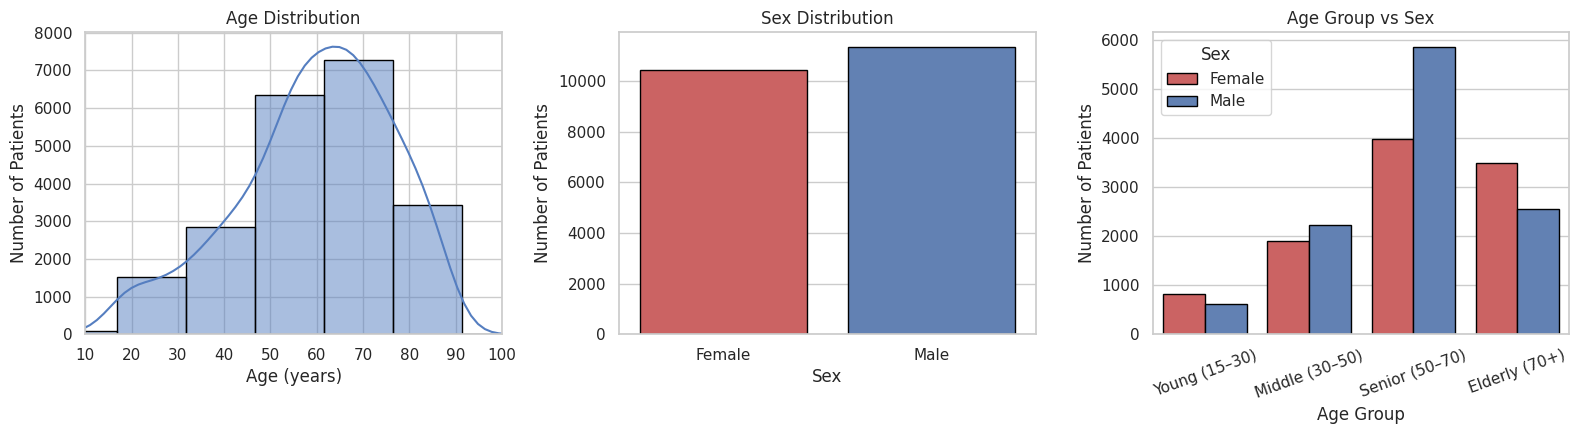

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Your custom colors
palette = {
    'Male': "#557EC0FF",   # blue
    'Female': "#DD5151"    # red
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Age distribution
sns.histplot(df['age'], bins=20, kde=True, ax=axes[0],
             edgecolor='black', color="#557EC0FF")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Number of Patients")
axes[0].set_xlim(10, 100)

# 2. Sex distribution (with custom colors + black edges)
sns.countplot(data=df, x='sex', ax=axes[1],
              palette=palette, edgecolor='black')
axes[1].set_title("Sex Distribution")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Number of Patients")

# 3. Age group + sex (same colors + edges)
sns.countplot(data=df, x='age_group', hue='sex', ax=axes[2],
              palette=palette, edgecolor='black')
axes[2].set_title("Age Group vs Sex")
axes[2].set_xlabel("Age Group")
axes[2].set_ylabel("Number of Patients")
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(title="Sex")

plt.tight_layout()
plt.savefig("demographic_overview.png", dpi=300, bbox_inches='tight')
plt.show()

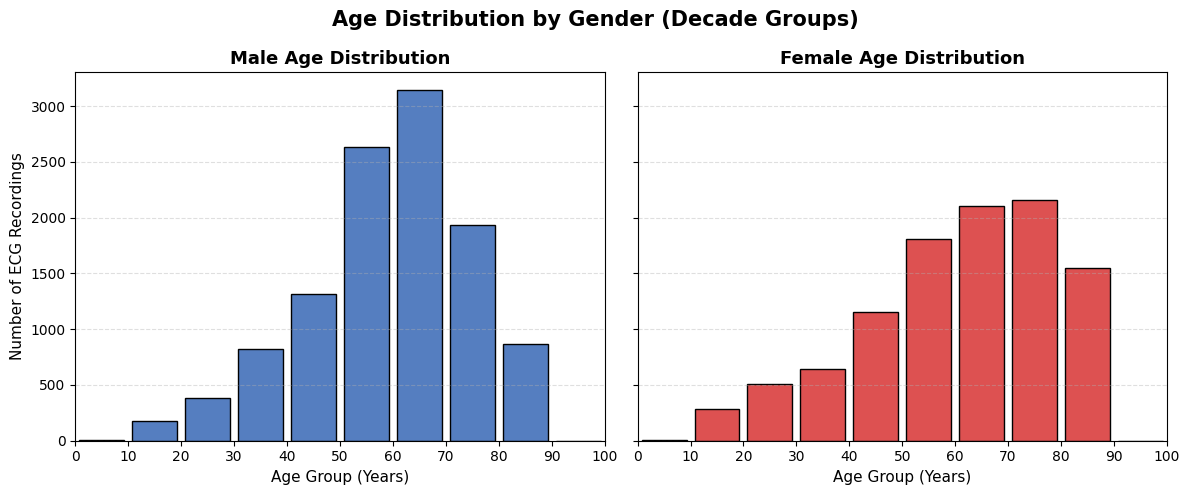

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure realistic age range
df = df[(df['age'] >= 0) & (df['age'] <= 100)]

# Age bins by decade
bins = np.arange(0, 110, 10)

male_age = df[df['sex'] == 'Male']['age']
female_age = df[df['sex'] == 'Female']['age']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Male Histogram (Blue)
axes[0].hist(
    male_age,
    bins=bins,
    edgecolor='black',
    rwidth=0.85,
    color="#557EC0FF"
)
axes[0].set_title("Male Age Distribution", fontsize=13, weight='bold')
axes[0].set_xlabel("Age Group (Years)", fontsize=11)
axes[0].set_ylabel("Number of ECG Recordings", fontsize=11)
axes[0].set_xticks(bins)
axes[0].set_xlim(0, 100)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Female Histogram (Orange)
axes[1].hist(
    female_age,
    bins=bins,
    edgecolor='black',
    rwidth=0.85,
    color="#DD5151"
)
axes[1].set_title("Female Age Distribution", fontsize=13, weight='bold')
axes[1].set_xlabel("Age Group (Years)", fontsize=11)
axes[1].set_xticks(bins)
axes[1].set_xlim(0, 100)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle("Age Distribution by Gender (Decade Groups)", fontsize=15, weight='bold')
plt.tight_layout()
plt.show()


In [33]:
gender_percentage = df['sex'].value_counts(normalize=True) * 100

print("Gender Percentage (%):")
print(gender_percentage.round(2))


Gender Percentage (%):
sex
Male      52.48
Female    47.52
Name: proportion, dtype: float64


In [29]:
summary_table = df.groupby('sex')['age'].agg(['count', 'mean', 'std', 'min', 'max'])

print("Demographic Summary Statistics:")
summary_table.round(2)


Demographic Summary Statistics:


,count,mean,std,min,max
sex,,,,,
Female,10445,65.56,39.09,3.0,300.0
Male,11354,60.20,24.18,2.0,300.0
